# Optimism-bias multiplier sweep — flip boundaries for the S2 headline claims

**What this notebook does.** The T9 stress in `tech_comparison.ipynb` inflates the drawn
2030 SMR anchor cost (the starting cost the learning curve descends from) by a single
optimism-bias multiplier m = 1.5, and that one point does not just break the majority
claim — it inverts the recommendation (P(SMR wins) falls to 0.002–0.21 at κ = 1, from a
0.82–0.89 baseline). This notebook sweeps m over 1.00–2.00 and reports, for each headline
claim of paper section S2, the **flip boundary** m* — the multiplier at which the claim
stops holding:

- **S2-d** (majority): SMR wins the majority of sampled worlds. Fails when the minimum
  over schedules of P(SMR wins) crosses 0.5 — the pre-registered C1 criterion.
- **S2-c claim 1** (EVPI): committing now, without waiting for perfect information,
  forfeits little. EVPI (the expected value of perfect information — the most a planner
  would pay to know the drawn world before committing) is judged against the
  pre-registered C5 "low value" threshold, 1% of expected program cost (2% also reported).
- **S2-c claim 2** (switch bound): one perfect-information technology switch in 2036
  recovers little. Same C5 threshold.
- **S2-b** (fragmentation): a split program dilutes learning. Fails when the median
  penalty of the 50/50 constant split, relative to the best pure program in the same
  drawn world, crosses zero.

**Engine.** Every model component is ported verbatim from `tech_comparison.ipynb` by
`_build_ob_sweep.py` with build-time content asserts — the sweep runs the production
marginals, copula, learning engine, durations, financing, and cost objects by
construction. The multiplier enters at its single production site: `marginal_ppf`'s
`variant="ob"` branch multiplies the drawn SMR anchor (`OB_MULT`), and deliberately does
NOT move the O&M percentile (the T1/T9 convention).

**Common random numbers, and one deliberate stream reuse.** At κ = 1 the worlds come from
the frozen `mc_perdraw.npz` uniforms, so every multiplier reuses the same latent draws and
the sweep is fully deterministic. At κ = 0.5 and κ = 0 the sweep draws with the SAME
stream names tech_comparison used for its ob cells (`tccomp/world/ob@{aid}/{tok}`), held
fixed across all m. Two consequences, both intended: (i) m = 1.5 reproduces the published
`stress_survival.csv` ob rows bit-for-bit, and (ii) every m shares latents, so the curves
in m are smooth and the interpolated boundaries are not draw-noise artifacts. The QA cell
at the end pins both ends of the sweep to the published exports.

**Outputs.** `exports/ob_sweep/{sweep_metrics.csv, flip_boundaries.csv,
ob_sweep_metadata.json}`, the diagnostic `figures/obs_flip_curves.png`, and the paper
Fig 3 panels `figures/{obs_majority_vs_m.png, obs_evpi_vs_m.png}` (baked letters c/d —
the sweep curves replaced the κ-profile insets in the 2026-08-26 Fig 3c/d swap; the
2026-08-31 third recomposition made the majority flip panel c and the EVPI sweep
panel d, and retired the standalone bound sweep `obs_bound_vs_m.png` from the paper).


In [1]:
# T0 — conventions, switches, claims-ledger scaffold. All analysis switches live here.
import json
import os
import time
import zlib
import hashlib
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

# --- Paths: anchored to this notebook's folder, never the launch directory ---
NB_DIR = Path.cwd() if Path.cwd().name == "mc" else Path("z-ethan/mc").resolve()
assert (NB_DIR / "pris_loader.py").exists(), f"notebook folder not found from {Path.cwd()}"
REPO_ROOT = NB_DIR.parent.parent               # the ReEDS-nuclear-learning fork
MC_EXPORTS = NB_DIR / "exports"                # the companion notebooks' exports (pins)
EXPORTS = NB_DIR / "exports" / "ob_sweep"
PERDRAW_DIR = EXPORTS / "perdraw"              # per-draw npz, gitignored
FIGURES = NB_DIR / "figures"
for d in (EXPORTS, PERDRAW_DIR, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

import sys
if str(NB_DIR) not in sys.path:                # make `import pris_loader` work from any launch dir
    sys.path.insert(0, str(NB_DIR))

NPZ_PATH = MC_EXPORTS / "mc_perdraw.npz"
assert NPZ_PATH.exists(), "exports/mc_perdraw.npz not found - run mc_cost_trajectories.ipynb first"

# --- Reproducibility: one master seed, independent named streams, every stream prefixed
# "tccomp/" so no stream can collide with any companion notebook's draws. Every stream
# name ever requested is recorded for the T10 seed-stream audit.
MASTER_SEED = 20260715
STREAMS_USED = []

def rng_stream(name):
    """An independent, reproducible random generator tied to a label (audited)."""
    assert name.startswith("tccomp/"), f"stream '{name}' missing the tccomp/ prefix"
    STREAMS_USED.append(name)
    return np.random.default_rng(np.random.SeedSequence((MASTER_SEED, zlib.crc32(name.encode()))))

# --- Analysis switches (rationale on every line; ratified 2026-08-06) ---
KAPPA_SWEEP = [1.0, 0.75, 0.5, 0.25, 0.0]  # the primary diagonal (kappa_lr = kappa_boak)
ANCHOR_KAPPAS = [1.0, 0.5, 0.0]            # anchor cells: variants run here only
SPLIT_PROBES = [(0.0, 1.0), (1.0, 0.0)]    # (kappa_lr, kappa_boak): "anchors ATB-coherent,
                                           # learning decoupled" + its mirror
RHO_WITHIN = -0.3                          # within-tech lr<->boak latent corr (companion
                                           # "moderate" set - untouched, see naming note)
N_DRAWS_TC = int(os.environ.get("OBSWEEP_DRAWS", 10000))  # per (cell, schedule); any cell
                                           # run below 10k is RECORDED in metadata (no
                                           # silent caps - spec draw-count rule)
COST_OBJ_DEFAULT = "npv"                   # full program NPV (T3); capex = historical pin
ITC_GRID = [0.0, 0.3]                      # OBBBA parity, both techs; shown once (T3/T9)
FLEX_GRID = [0.0, 25.0, 50.0]              # $/kW-yr off SMR levelized FOM - a BOUND on the
                                           # dispatch asymmetry (mingen 0.4 vs 0.7), not a model
PHI_GRID = [0.0, 0.3, 0.5]                 # learning floor OCC_t >= phi*BOAK (T9); 0.5 = headline
OB_MULT = 1.5                              # optimism-bias: SMR-only anchor multiplier (T1)
NEGLR_LO = -0.15                           # negative-learning lower endpoint (France; US -30%
                                           # rejected - post-TMI shock)
C2_THRESH_PCT = 5.0                        # C2: P95 |margin| under large wins, % of program cost
C5_THRESH_PCT = 1.0                        # C5: adaptive option value, % of expected program cost
REP_SCHED = "McKinsey GEP 2025"            # representative schedule for worked examples

# --- The pre-registered claims, loaded as data (ratified 2026-08-06, before any grid run).
# Later cells stamp each claim with (supported, region, source cell, numbers).
CLAIMS = {
    "C1": dict(statement="SMR is the majority pure-program winner (P > 0.5) in every "
                         "schedule at every primary cell",
               falsified_by="any primary cell with P(SMR) < 0.5"),
    "C2": dict(statement="'when large wins, it wins narrowly': P95 of |margin| | large wins "
                         f"< {C2_THRESH_PCT}% of program cost at every primary cell",
               falsified_by="tail above threshold anywhere (expected to fail at low kappa - "
                            "pre-registered so the failure is a finding)"),
    "C3": dict(statement="Pure-SMR minimizes expected program NPV among all fixed strategies "
                         "in every schedule at every primary cell",
               falsified_by="any fixed strategy (incl. hedge mixes) beating it on E[cost]"),
    "C4": dict(statement="Pure-SMR second-order stochastically dominates pure-large at every "
                         "primary cell",
               falsified_by="an SSD crossing -> report location, downgrade to 'holds at CVaR95'"),
    "C5": dict(statement="Perfect-information option value of the 2036 switch is "
                         f"< {C5_THRESH_PCT}% of expected program cost in every schedule",
               falsified_by=">= 1% anywhere -> sequencing gets paper space"),
    "C6": dict(statement="C1 and C3 survive each single stress cell (OB x1.5, NEGLR sym, "
                         "NEGLR large_only, phi=0.5, FLEX_CREDIT, capex object, ITC) at the "
                         "three anchor kappa cells",
               falsified_by="a breaking cell -> named in the paper with its numbers"),
    "C7": dict(statement="No claim is made outside the ordered orthant (A2 off = modularity "
                         "premise fails); scope cells reported once as the boundary of validity",
               falsified_by="n/a (a scope statement; stamped with the scope-cell numbers)"),
}
for c in CLAIMS.values():
    c.update(supported=None, region="", source="", numbers="")

def stamp(cid, supported, region, source, numbers):
    CLAIMS[cid].update(supported=bool(supported), region=region, source=source, numbers=numbers)
    print(f"[ledger] {cid} {'SUPPORTED' if supported else 'NOT SUPPORTED'} - {numbers}")

# --- Figure formatting: the z-ethan house standard (single source: ../plotstyle.py) ---
if str(NB_DIR.parent) not in sys.path:
    sys.path.insert(0, str(NB_DIR.parent))
import plotstyle as ps
ps.apply()
COL = ps.COL                                   # local aliases keep downstream cells unchanged
INK, MUTED, FAINT, GRID_C, EDGE_C, SURFACE = (ps.INK, ps.MUTED, ps.FAINT, ps.GRID_C,
                                              ps.EDGE_C, ps.SURFACE)
CMAP_PSMR = ps.cmap_div()                      # diverging: large-blue .. neutral .. smr-orange

print(f"notebook dir : {NB_DIR}")
print(f"grid         : kappa sweep {KAPPA_SWEEP}, anchors {ANCHOR_KAPPAS}, "
      f"probes {SPLIT_PROBES}, N = {N_DRAWS_TC}/cell/schedule")
print(f"claims       : {len(CLAIMS)} pre-registered (C1-C7), thresholds "
      f"C2 < {C2_THRESH_PCT}%, C5 < {C5_THRESH_PCT}%")
print("discipline   : every probability below is conditional on (dependence cell, "
      "marginal variant, schedule); no unconditional statement leaves this notebook")

notebook dir : C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc
grid         : kappa sweep [1.0, 0.75, 0.5, 0.25, 0.0], anchors [1.0, 0.5, 0.0], probes [(0.0, 1.0), (1.0, 0.0)], N = 10000/cell/schedule
claims       : 7 pre-registered (C1-C7), thresholds C2 < 5.0%, C5 < 1.0%
discipline   : every probability below is conditional on (dependence cell, marginal variant, schedule); no unconditional statement leaves this notebook


## Ported foundations

Verbatim from `tech_comparison.ipynb` (ported at build time by `_build_ob_sweep.py` with
content asserts): the six deployment schedules, historical and international experience,
foreign stocks and gross additions, the learning-curve engine, durations and financing,
the marginal variants (including the `OB_MULT` optimism-bias site), the latent copula and
cell draws, and the blended program costing with the 49-candidate strategy library.


In [2]:
# The six deployment schedules - read from the single source of truth, never redefined.
US_GW_2024 = 97.0
OFFSET_GW = 3.0

US_SCHEDULES_CSV = REPO_ROOT / "inputs" / "nuclear_learning" / "US_SCHEDULES.csv"
_sched_df = pd.read_csv(US_SCHEDULES_CSV, comment="#", index_col="year")

YEARS = np.arange(2024, 2051)
T = len(YEARS)
def yi(y):
    """Index of calendar year y in the YEARS grid."""
    return int(np.where(YEARS == y)[0][0])

ANCHOR = 2030
N_BOAK_UNITS = 2.0
OMEGA = 1.0 / 3.0
CES_RHO_GRID = np.array([-1.0, 0.0, 1.0])
X_SPILL_MAX = 0.30       # cross-tech spillover draw bound (kept: 2026-08-06 routing decision)
TECH = {
    "large": {"unit_gw": 1.000, "lr_lo": 0.03, "lr_hi": 0.12,
              "boak_lo": 5250.0, "boak_hi": 7750.0},
    "smr":   {"unit_gw": 0.300, "lr_lo": 0.03, "lr_hi": 0.16,
              "boak_lo": 5500.0, "boak_hi": 10000.0},
}
UNIT_FOREIGN_GW = 1.0
U_GRID = np.linspace(0.0, 1.0, 21)

TOKEN_NAME = {"eia_aeo_high": "EIA 2026 AEO high", "abou_jaoude": "Abou-Jaoude mod",
              "iaea_high": "IAEA high", "mckinsey": "McKinsey GEP 2025",
              "cop28": "COP28 tripling pledge", "eo2025": "2025 EO"}
assert set(_sched_df.columns) == set(TOKEN_NAME), "US_SCHEDULES.csv columns changed"
assert list(_sched_df.index) == list(YEARS), "US_SCHEDULES.csv year grid changed"

US_SCHEDULES = {TOKEN_NAME[tok]: _sched_df[tok].to_numpy(float) for tok in TOKEN_NAME}
SCHED_ORDER = list(US_SCHEDULES)
SCEN_TOKEN = {v: k for k, v in TOKEN_NAME.items()}

BUILD_YEARS = np.arange(2031, 2051)
N_P = len(BUILD_YEARS)
BUILD_SLICE = slice(yi(2031), yi(2050) + 1)

print("schedules loaded (2050 capacity in working GW basis):")
for name in SCHED_ORDER:
    print(f"  {name:22s} {US_SCHEDULES[name][-1] - OFFSET_GW:5.0f} GW")

schedules loaded (2050 capacity in working GW basis):
  EIA 2026 AEO high        114 GW
  Abou-Jaoude mod          131 GW
  IAEA high                169 GW
  McKinsey GEP 2025        197 GW
  COP28 tripling pledge    297 GW
  2025 EO                  397 GW


In [3]:
# Historical and international experience - ported verbatim from the companion S3 via
# mixed_build_optimizer (regional milestones, PRIS load, retirement identity, committed
# pipeline, historical stocks). See mc_cost_trajectories S3 for the full walkthrough.
REGION_MILESTONES = {
    "CA":  (12.7, 12.7, 12.7, 18.8, 23.0, 30.0, 63.7),
    "SAM": (5.1, 5, 5, 8, 11, 8, 20),
    "WEU": (95.4, 86, 92, 81, 114, 68, 136),
    "EEU": (53.6, 57, 57, 58, 82, 68, 103),
    "AF":  (1.9, 4, 5, 7, 12, 12, 30),
    "WA":  (5.8, 11, 11, 12, 20, 15, 35),
    "SA":  (11.1, 18, 22, 25, 43, 45, 85),
    "CEA": (94.5, 136, 144, 215, 264, 242, 328),
    "SEA": (0, 0, 0, 3, 7, 4, 18),
    "OC":  (0, 0, 0, 0, 0, 0, 2),
}
THETA_KV = {"CA": 0.28, "SAM": 0.14, "WEU": 0.17794117647, "EEU": 0.1325, "AF": 0.16688725490,
            "WA": 0.13375, "SA": 0.185, "CEA": 0.135, "SEA": 0.16583333, "OC": 0.18}
REGIONS = list(THETA_KV.keys())

import pris_loader as pl

PRIS_UNITS = pl.load_units(str(NB_DIR / "rds2_2025_units.csv"))
_milestones_2024 = {r: REGION_MILESTONES[r][0] for r in REGIONS} | {"US": US_GW_2024}
_issues = pl.validate_units(PRIS_UNITS[PRIS_UNITS["status"] == "operational"], _milestones_2024)
assert not _issues, _issues

FLEET = PRIS_UNITS[PRIS_UNITS["status"] == "operational"]
UC_UNITS = PRIS_UNITS[PRIS_UNITS["status"] == "under construction"]

def retirement_flow_gw(key, life_yr):
    """GW retiring per model year, from each unit's real grid-connection date + a lifetime rule."""
    return pl.retirement_schedule(FLEET, pd.Index(YEARS), lifetime_years=life_yr,
                                  region=key).to_numpy()

PIPE_END = 2030   # pipeline's real visibility horizon; structurally zero after 2030 (mc S3)
PIPELINE_GW = {r: pl.committed_pipeline(UC_UNITS[UC_UNITS["region"] == r],
                                        pd.Index(np.arange(2025, PIPE_END + 1)),
                                        lead_time_months=72).to_dict()
               for r in REGIONS}

_ever = PRIS_UNITS[(PRIS_UNITS["status"] != "under construction")
                   & PRIS_UNITS["grid_connection"].notna()]
HIST_UNITS = {r: int((_ever["region"] == r).sum()) for r in REGIONS + ["US"]}

US_LICENSE_LIFE = 80.0
ONE_FACTOR_DELTA = 0.0

print(f"PRIS fleet loaded: {len(FLEET)} operational, {len(UC_UNITS)} under construction")

PRIS fleet loaded: 417 operational, 62 under construction


In [4]:
# Foreign stocks on the u grid + per-schedule gross GW additions (ported verbatim).
def net_path_gw(region, u):
    """Regional net capacity path: interpolate the 2024/2030/2040/2050 milestones, positioned
    between Low and High by the global deployment draw u."""
    c = REGION_MILESTONES[region]
    vals = [c[0], c[1] + u*(c[2]-c[1]), c[3] + u*(c[4]-c[3]), c[5] + u*(c[6]-c[5])]
    return np.interp(YEARS, [2024, 2030, 2040, 2050], vals)

def gross_additions_gw(region, u):
    """The retirement identity: builds = max(0, capacity change + retirements); the committed
    pipeline REPLACES the interpolated path through PIPE_END = 2030."""
    dnet = np.diff(net_path_gw(region, u), prepend=net_path_gw(region, u)[0])
    ret = retirement_flow_gw(region, 65.0 + 5.0*u)   # IAEA-calibrated lives, 65+5u
    g = np.clip(dnet + ret, 0.0, None)
    pipe_mask = YEARS <= PIPE_END
    g[pipe_mask] = [PIPELINE_GW[region].get(int(y), 0.0) for y in YEARS[pipe_mask]]
    return g

REGION_STOCK = {}
for r in REGIONS:
    m_a = np.empty((len(U_GRID), T))
    for gi, u in enumerate(U_GRID):
        flow = gross_additions_gw(r, u)
        flow = flow.copy(); flow[YEARS <= ANCHOR] = 0.0
        m_a[gi] = np.cumsum(flow) / UNIT_FOREIGN_GW
    REGION_STOCK[r] = m_a

US_RET = retirement_flow_gw("US", US_LICENSE_LIFE)
GW_ADD = {}
for name in SCHED_ORDER:
    cap = US_SCHEDULES[name] - OFFSET_GW
    dnet = np.diff(cap, prepend=cap[0])
    flow = np.clip(dnet + US_RET, 0.0, None)
    flow[YEARS <= ANCHOR] = 0.0
    GW_ADD[name] = flow

print("total post-2030 gross additions per schedule (GW):")
for name in SCHED_ORDER:
    print(f"  {name:22s} {GW_ADD[name].sum():6.1f} GW over {int((GW_ADD[name] > 0).sum())} build years")

total post-2030 gross additions per schedule (GW):
  EIA 2026 AEO high        20.7 GW over 15 build years
  Abou-Jaoude mod          36.4 GW over 20 build years
  IAEA high                75.7 GW over 20 build years
  McKinsey GEP 2025       103.4 GW over 20 build years
  COP28 tripling pledge   203.4 GW over 20 build years
  2025 EO                 303.4 GW over 20 build years


In [5]:
# The learning-curve engine - verbatim port (mixed_build_optimizer / mc S5). Cross-tech
# spillover via n_oth/x_in; S_KV caching for hot loops. QA-A pins this bit-for-bit.
H_ALL_W = sum(THETA_KV[r]*HIST_UNITS[r] for r in REGIONS)   # theta-weighted historical foreign stock

def lag1(a):
    """One-year completion lag along the time axis: the stock ENTERING year t is the builds
    completed through t-1 (applied at the pricing boundary; companion-identical)."""
    a = np.asarray(a, float)
    out = np.zeros_like(a)
    out[..., 1:] = a[..., :-1]
    return out

OTHER_TECH = {"large": "smr", "smr": "large"}
X_IN_COL = {"large": "x_sl", "smr": "x_ls"}     # incoming cross-tech fraction, per receiving tech

def intl_stock(world):
    """Theta-weighted foreign post-anchor stock, (n_draws, T), UNLAGGED - depends only on the
    drawn u, so callers evaluating many share profiles compute it once and pass it back in."""
    n = len(world)
    u_r = np.repeat(world["u"].values[:, None], len(REGIONS), axis=1)
    gi = np.clip(np.rint(u_r * (len(U_GRID)-1)).astype(int), 0, len(U_GRID)-1)
    S = np.zeros((n, T))
    for j, r in enumerate(REGIONS):
        S += THETA_KV[r] * REGION_STOCK[r][gi[:, j], :]
    return S

def experience_channels(world, tech, n_us, n_oth=None, x_in=None, S_KV=None):
    """The two experience stocks O_d(t) (own) and A_d(t) (cross-firm), each (n_draws, T).
    Companion-identical math (mc S5); x_in/S_KV are hot-loop conveniences asserted neutral
    in QA-A. n_oth is the OTHER technology's cumulative post-anchor US units."""
    n = len(world)
    if S_KV is None:
        S_KV = intl_stock(world)
    skv = lag1(S_KV)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))
    conv = world["conv_full"].values[:, None].astype(float)
    m = world["n_vendors"].values[:, None].astype(float)
    s = world["s"].values[:, None]
    # US historical fleet counts toward LARGE only (companion D8'): the SMR learning-rate
    # range already embeds any benefit from the prior LWR builds.
    hist_us = HIST_UNITS["US"] if tech == "large" else 0.0
    own0 = N_BOAK_UNITS + conv*hist_us/m
    own = own0 + N_us/m
    oth = (m-1.0)*own0 + N_us*(m-1.0)/m \
          + s*(conv*H_ALL_W + skv)
    if n_oth is not None:
        x = np.asarray(world[X_IN_COL[tech]].values if x_in is None else x_in, float)
        if x.ndim == 1:
            x = x[:, None]
        N_oth = lag1(np.broadcast_to(np.asarray(n_oth, float), (n, T)))
        oth = oth + x * N_oth
    return own, oth

CES_EPS = 1e-8

def occ_paths_ces(world, tech, n_us, n_oth=None, x_in=None, ces_rho=None, S_KV=None):
    """Production OCC engine (companion D11/D12, ported verbatim). $/kW (2022 USD), (n_draws, T).
    Note the engine is well-defined for NEGATIVE learning rates (b flips sign, costs rise
    with experience) - the NEGLR marginal variant relies on this; lr = 0 exactly would be
    a 0/0 in the weight w, which the draw cell excludes (measure zero, nudged)."""
    own, oth = experience_channels(world, tech, n_us, n_oth=n_oth, x_in=x_in, S_KV=S_KV)
    assert own.min() >= N_BOAK_UNITS and oth.min() >= N_BOAK_UNITS, "stock below anchor base; log unsafe"
    lr = world[f"lr_{tech}"].values[:, None]
    b1, b2 = np.log2(1.0 - lr), np.log2(1.0 - OMEGA*lr)
    b, w = -(b1 + b2), b1/(b1 + b2)
    rho = world["ces_rho"].values if ces_rho is None else np.full(len(world), float(ces_rho))
    rho = rho[:, None]
    geo = np.abs(rho) < CES_EPS
    lnO, lnA = np.log(own), np.log(oth)
    with np.errstate(over="raise"):
        lnE = np.where(geo, w*lnO + (1.0-w)*lnA,
                       lnO + np.log1p((1.0-w)*np.expm1(np.where(geo, 0.0, rho)*(lnA - lnO)))
                           / np.where(geo, 1.0, rho))
    return world[f"boak_{tech}"].values[:, None] * np.exp(-b*(lnE - lnE[:, [yi(ANCHOR)]]))

def percentile_table(paths, ps=(5, 25, 50, 75, 95)):
    """Yearly percentiles of a (n_draws, T) trajectory array."""
    return pd.DataFrame({f"P{p}": np.percentile(paths, p, axis=0) for p in ps}, index=YEARS)

print(f"engine loaded: theta-weighted historical foreign stock H = {H_ALL_W:.1f} units")

engine loaded: theta-weighted historical foreign stock H = 83.5 units


In [6]:
# Construction durations and financing - verbatim ports (companion S6-S7 via mixed_build).
DUR_UNITS = pl.duration_panel(PRIS_UNITS)
DUR_UNITS = DUR_UNITS[DUR_UNITS["family"].isin(["AP1000", "APR1400", "HPR1000"])].reset_index(drop=True)
DUR_UNITS = DUR_UNITS.rename(columns={"reactor_name": "unit"})

def fit_family_fe(df):
    """ln(duration) = family intercepts + b*ln(family sequence); returns (coefficients, residual sd)."""
    X = np.column_stack([np.ones(len(df)),
                         (df["family"] == "APR1400").astype(float),
                         (df["family"] == "HPR1000").astype(float),
                         np.log(df["family_seq"].astype(float))])
    Y = np.log(df["months"].values)
    beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ beta
    return beta, resid.std(ddof=min(4, len(df)-1))

beta_hat, sig_hat = fit_family_fe(DUR_UNITS)

INL_DUR_MOD = np.array([118.0, 88.0, 74.0, 67.0, 62.0, 59.0, 56.0, 54.0, 52.0, 50.0])
INL_DUR_OPT = np.array([118.0, 70.0, 57.0, 49.0, 45.0, 42.0, 40.0, 38.0, 37.0, 36.0])
SMR_DUR_RATIO = 55.0/82.0
SMR_DUR_FLOOR = 43.0

def duration_paths(world, tech, n_us):
    """Construction duration (months) per draw-year from the INL series curves; the series
    clock runs on a vendor's OWN projects only (spillover never shortens schedules)."""
    n = len(world)
    N_us = lag1(np.broadcast_to(np.asarray(n_us, float), (n, T)))
    n_own = N_us / world["n_vendors"].values[:, None]
    series = np.clip(2 + np.floor(n_own/2.0).astype(int), 2, len(INL_DUR_MOD))
    opt, mod = np.take(INL_DUR_OPT, series-1), np.take(INL_DUR_MOD, series-1)
    base = opt + world["dur_lambda"].values[:, None]*(mod - opt)
    if tech == "smr":
        base = np.maximum(base * SMR_DUR_RATIO, SMR_DUR_FLOOR)
    return base * np.exp(world["dur_z"].values[:, None]*sig_hat)

FIN_DIR = REPO_ROOT / "inputs" / "financials"

def load_reeds_financials():
    """ReEDS financial inputs on the YEARS grid, exactly as reeds/financials.py derives them."""
    sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
    infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
    sys_fin = sys_fin.merge(infl, on="t", how="left")
    sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                        + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                          * (1 - sys_fin["tax_rate"]) + 1)
    sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
    tech_fin = pd.read_csv(FIN_DIR / "financials_tech_ATB2024.csv")
    tech_fin = tech_fin[tech_fin["i"].isin(["Nuclear", "Nuclear-SMR"])]
    dep = pd.read_csv(FIN_DIR / "depreciation_schedules_default.csv")
    cs = pd.read_csv(FIN_DIR / "construction_schedules_default.csv")

    def on_years(col):
        s = sys_fin.set_index("t")[col].reindex(range(1990, YEARS[-1] + 1)).ffill()
        return s.loc[YEARS].to_numpy(float)

    out = {"interest_base": on_years("interest_rate_nom"), "tax_rate": on_years("tax_rate"),
           "d_nom": on_years("d_nom"), "d_real": on_years("d_real"),
           "pv_dep": {}, "risk_mult": {}, "eval_adj": {}, "sched": {}}
    SYS_EVAL_YEARS = 30
    sys_pvf_sum = (1 - (1/out["d_real"])**(SYS_EVAL_YEARS - 1)) / (out["d_real"] - 1.0) + 1
    REEDS_TECH_NAME = {"large": "Nuclear", "smr": "Nuclear-SMR"}
    for tech, iname in REEDS_TECH_NAME.items():
        row = tech_fin[tech_fin["i"] == iname].iloc[-1]
        dep_frac = dep[str(int(row["depreciation_sch"]))].to_numpy(float)
        out["pv_dep"][tech] = np.array([np.sum(dep_frac / dn**np.arange(1, 22))
                                        for dn in out["d_nom"]])
        eval_p = float(row["eval_period"])
        out["risk_mult"][tech] = 1.0 + float(row["finance_diff_real"]) * (
            (1 - (1/out["d_real"])**eval_p) / (out["d_real"] - 1.0))
        tech_pvf_sum = (1 - (1/out["d_real"])**(eval_p - 1)) / (out["d_real"] - 1.0) + 1
        out["eval_adj"][tech] = sys_pvf_sum / tech_pvf_sum
        frac = pd.to_numeric(cs[str(row["construction_sch"])], errors="coerce").fillna(0.0).to_numpy()
        nz = np.flatnonzero(frac > 0)
        assert nz.size and nz[-1] - nz[0] + 1 == nz.size, \
            f"{iname}: spend profile has interior zeros"
        out["sched"][tech] = frac[nz[0]:nz[-1] + 1]
    return out

FIN = load_reeds_financials()

def _resample_schedule(frac, n_years):
    """Stretch/compress a spend-fraction profile to n_years bins (sum to 1)."""
    frac = np.asarray(frac, float)
    n0 = len(frac)
    if n_years == n0:
        return frac / frac.sum()
    cdf = np.concatenate([[0.0], np.cumsum(frac)])
    xq = np.linspace(0.0, 1.0, n_years + 1)
    cdf_q = np.interp(xq, np.linspace(0.0, 1.0, n0 + 1), cdf)
    new = np.diff(cdf_q)
    return new / new.sum()

def ccmult_from_duration(duration_mo, interest_base, canonical_frac):
    """Construction-financing (IDC) multiplier for a learned duration (verbatim ReEDS port)."""
    n_years = int(round(duration_mo / 12.0))
    n_years = max(1, min(n_years, 10))
    x = _resample_schedule(canonical_frac, n_years)
    exps = np.arange(n_years) + 0.5
    return 1.0 + float(np.sum(x * (interest_base ** exps - 1.0)))

def _ccm_table(tech):
    ib = FIN["interest_base"]
    table = np.empty((10 + 1, T))
    for nyr in range(1, 11):
        x = _resample_schedule(FIN["sched"][tech], nyr)
        exps = np.arange(nyr) + 0.5
        table[nyr] = 1.0 + (x[:, None] * (ib[None, :] ** exps[:, None] - 1.0)).sum(axis=0)
    return table

CCM_TABLE = {tech: _ccm_table(tech) for tech in TECH}

def ccmult_grid(dur_months, tech):
    """Vectorized ccmult for a (n_draws, T) duration array."""
    n_years = np.clip(np.round(np.asarray(dur_months)/12.0).astype(int), 1, 10)
    return CCM_TABLE[tech][n_years, np.arange(T)[None, :]]

def fin_mult_rest(tech):
    """Everything in ReEDS's cost_cap_fin_mult EXCEPT ccmult, per year (T,) - verbatim port.
    The T3 ITC variant is applied downstream as a stylized (1 - ITC) scalar on financed
    CAPEX for BOTH techs (OBBBA parity), not here."""
    tax, pv_dep = FIN["tax_rate"], FIN["pv_dep"][tech]
    return (1.0/(1.0 - tax)) * (1.0 - tax*pv_dep) * FIN["risk_mult"][tech] * FIN["eval_adj"][tech]

FIN_REST = {tech: fin_mult_rest(tech) for tech in TECH}
DISC = np.cumprod(np.where(YEARS > ANCHOR, FIN["d_real"], 1.0))   # discount to 2030

print(f"duration panel: {len(DUR_UNITS)} units, residual sd = {sig_hat:.3f} log-months")
print("financing loaded; full multiplier at 2035, at each tech's default duration:")
for tech, default_mo in [("large", 72.0), ("smr", 36.0)]:
    ccm = ccmult_from_duration(default_mo, FIN["interest_base"][yi(2035)], FIN["sched"][tech])
    print(f"  {tech}: ccmult = {ccm:.4f}, fin_mult_noITC = {ccm*FIN_REST[tech][yi(2035)]:.4f}")

duration panel: 21 units, residual sd = 0.116 log-months
financing loaded; full multiplier at 2035, at each tech's default duration:
  large: ccmult = 1.2681, fin_mult_noITC = 1.5145
  smr: ccmult = 1.0898, fin_mult_noITC = 1.3015


In [7]:
# T1 - marginal ranges, variant transforms, and the provenance table.
LR_RANGE = {"large": (TECH["large"]["lr_lo"], TECH["large"]["lr_hi"]),
            "smr": (TECH["smr"]["lr_lo"], TECH["smr"]["lr_hi"])}
BOAK_RANGE = {"large": (TECH["large"]["boak_lo"], TECH["large"]["boak_hi"]),
              "smr": (TECH["smr"]["boak_lo"], TECH["smr"]["boak_hi"])}

# ATB 2024 moderate 2030 capital costs = the PERT modes (read, never hard-coded)
_ATB_STEM = {"large": "nuclear", "smr": "nuclear-smr"}
def atb_row(tech, scen):
    f = REPO_ROOT / "inputs" / "plant_characteristics" / f"{_ATB_STEM[tech]}_ATB_2024_{scen}.csv"
    return pd.read_csv(f).set_index("t").loc[2030]

BOAK_MODE = {t: float(atb_row(t, "moderate")["capcost"]) for t in TECH}
for t in TECH:   # the anchor ranges ARE the ATB advanced/conservative endpoints
    assert (float(atb_row(t, "advanced")["capcost"]),
            float(atb_row(t, "conservative")["capcost"])) == BOAK_RANGE[t], t
assert BOAK_RANGE["large"][0] < BOAK_MODE["large"] < BOAK_RANGE["large"][1]
assert BOAK_RANGE["smr"][0] < BOAK_MODE["smr"] < BOAK_RANGE["smr"][1]

def pert_ppf(U, lo, mode, hi, lam=4.0):
    """Inverse CDF of the PERT(lo, mode, hi) distribution (Beta reparameterization)."""
    a = 1.0 + lam * (mode - lo) / (hi - lo)
    b = 1.0 + lam * (hi - mode) / (hi - lo)
    return lo + (hi - lo) * stats.beta.ppf(U, a, b)

def marginal_ppf(U, kind, tech, variant):
    """Transform a latent uniform into a drawn value under the given marginal variant.
    kind in {'lr','boak'}; variant in {'default','ob','neglr_sym','neglr_large','pert'}."""
    if kind == "lr":
        lo, hi = LR_RANGE[tech]
        if variant == "neglr_sym" or (variant == "neglr_large" and tech == "large"):
            lo = NEGLR_LO
        if variant == "pert":
            v = pert_ppf(U, lo, 0.5*(lo + hi), hi)     # mode at midpoint (documented judgment)
        else:
            v = lo + U*(hi - lo)
        # lr = 0 exactly is a 0/0 in the engine's channel weight; measure-zero, nudged.
        return np.where(v == 0.0, 1e-9, v)
    lo, hi = BOAK_RANGE[tech]
    if variant == "pert":
        v = pert_ppf(U, lo, BOAK_MODE[tech], hi)
    else:
        v = lo + U*(hi - lo)
    if variant == "ob" and tech == "smr":
        v = OB_MULT * v                                # SMR-only optimism-bias multiplier
    return v

VARIANTS = ["default", "ob", "neglr_sym", "neglr_large", "pert"]

_SRC_INL = "INL/RPT-24-77048 Rev 2 (symmetric GN-COA processing; asymmetric evidence classes)"
MARGINAL_TABLE = pd.DataFrame([
    ("lr_large", "U(0.03, 0.12)", "uniform (pert/neglr variants)", _SRC_INL + "; realized-build anchored"),
    ("lr_smr", "U(0.03, 0.16)", "uniform (pert/neglr variants)", _SRC_INL + "; vendor bottom-up, zero built"),
    ("boak_large", "U(5250, 7750) $/kW", "uniform (pert variant)", "ATB 2024 advanced..conservative 2030 capcost"),
    ("boak_smr", "U(5500, 10000) $/kW", "uniform (pert; OB x1.5)", "ATB 2024 advanced..conservative 2030 capcost"),
    ("u", "U(0, 1)", "uniform", "global deployment position (IAEA Low..High milestones)"),
    ("s", "U(0, 1)", "uniform", "international spillover scale (K&V theta weighting)"),
    ("n_vendors", "{4..8}", "discrete uniform", "vendor-count judgment (mc S4)"),
    ("conv_full", "{0, 1}", "Bernoulli(0.5)", "experience-base convention (per-tech; D8')"),
    ("ces_rho", "{-1, 0, 1}", "discrete uniform", "CES channel substitution (mc S15)"),
    ("dur_lambda", "U(0, 1)", "uniform", "INL duration scenario position"),
    ("dur_z", "N(0, sig_hat)", "lognormal residual", "PRIS duration panel residual"),
    ("x_ls / x_sl", f"U(0, {X_SPILL_MAX})", "uniform", "cross-tech spillover (K&V-normalized; 2026-08-06)"),
], columns=["parameter", "support", "shape", "source"]).set_index("parameter")
MARGINAL_TABLE["decision_sensitivity"] = "(backfilled by T8)"
print("marginals (production elicitation; variants transform the same latent uniforms):")
print(MARGINAL_TABLE.drop(columns="decision_sensitivity").to_string())
print(f"\nOB effective SMR anchor range: ${OB_MULT*BOAK_RANGE['smr'][0]:,.0f}"
      f"-{OB_MULT*BOAK_RANGE['smr'][1]:,.0f}/kW; PERT modes: large ${BOAK_MODE['large']:,.0f}, "
      f"smr ${BOAK_MODE['smr']:,.0f} (ATB moderate)")

marginals (production elicitation; variants transform the same latent uniforms):
                         support                          shape                                                                                                           source
parameter                                                                                                                                                                       
lr_large           U(0.03, 0.12)  uniform (pert/neglr variants)       INL/RPT-24-77048 Rev 2 (symmetric GN-COA processing; asymmetric evidence classes); realized-build anchored
lr_smr             U(0.03, 0.16)  uniform (pert/neglr variants)  INL/RPT-24-77048 Rev 2 (symmetric GN-COA processing; asymmetric evidence classes); vendor bottom-up, zero built
boak_large    U(5250, 7750) $/kW         uniform (pert variant)                                                                     ATB 2024 advanced..conservative 2030 capcost
boak_smr     U(5500, 10000) $/kW  

In [8]:
# T2 - the latent copula, the cell draw, and the kappa=1 npz reconstruction.
U_COLS = ["u_lr_large", "u_lr_smr", "u_boak_large", "u_boak_smr"]

def latent_corr(k_lr, k_boak, r=RHO_WITHIN):
    """Correlation matrix over the DISTINCT latents (duplicated latents at kappa=1 are
    shared columns, never sampled twice). Returns (C, names, slot) where slot maps each
    of the five conceptual latents to a column of C."""
    names = ["lr_L"] + ([] if k_lr >= 1.0 else ["lr_S"]) \
          + ["boak_L"] + ([] if k_boak >= 1.0 else ["boak_S"]) + ["u"]
    ix = {nm: i for i, nm in enumerate(names)}
    slot = {"lr_L": ix["lr_L"], "lr_S": ix.get("lr_S", ix["lr_L"]),
            "boak_L": ix["boak_L"], "boak_S": ix.get("boak_S", ix["boak_L"]), "u": ix["u"]}
    c_cross = r * max(k_lr, k_boak)         # forced to r by duplication consistency (see md)
    C = np.eye(len(names))
    def put(a, b, v):
        if a in ix and b in ix:
            C[ix[a], ix[b]] = C[ix[b], ix[a]] = v
    put("lr_L", "lr_S", k_lr)
    put("boak_L", "boak_S", k_boak)
    put("lr_L", "boak_L", r)
    put("lr_S", "boak_S", r)
    put("lr_L", "boak_S", c_cross)
    put("lr_S", "boak_L", c_cross)
    ev = np.linalg.eigvalsh(C)
    assert ev.min() > 1e-10, f"latent correlation not PD at kappa=({k_lr},{k_boak}): {ev}"
    return C, names, slot

def _fill_common(w, rng, n):
    """The draw columns shared by every cell (mixed_build's order => stream-stable)."""
    w["s"] = rng.uniform(0.0, 1.0, n)
    w["n_vendors"] = rng.integers(4, 9, n)
    w["conv_full"] = rng.integers(0, 2, n)
    w["ces_rho"] = rng.choice(CES_RHO_GRID, size=n)
    w["dur_lambda"] = rng.uniform(0.0, 1.0, n)
    w["dur_z"] = rng.standard_normal(n)
    w["x_ls"] = rng.uniform(0.0, X_SPILL_MAX, n)
    w["x_sl"] = rng.uniform(0.0, X_SPILL_MAX, n)
    return w

def _apply_marginals(w, variant):
    """Latent uniforms -> drawn lr/boak columns under the variant's transforms."""
    for tech in TECH:
        w[f"lr_{tech}"] = marginal_ppf(w[f"u_lr_{tech}"].to_numpy(), "lr", tech, variant)
        w[f"boak_{tech}"] = marginal_ppf(w[f"u_boak_{tech}"].to_numpy(), "boak", tech, variant)
    return w

def _ordering_keep(w, a1, a2):
    keep = pd.Series(True, index=w.index)
    if a1:
        keep &= w["boak_smr"] > w["boak_large"]
    if a2:
        keep &= w["lr_smr"] > w["lr_large"]
    return keep

def draw_cell(n, k_lr, k_boak, a1, a2, variant, stream):
    """Rejection-draw n worlds for one (dependence cell, marginal variant). Latent order
    and common-column order are fixed, so a cell's draw is stream-stable."""
    C, names, slot = latent_corr(k_lr, k_boak)
    L = np.linalg.cholesky(C)
    rng = rng_stream(stream)
    frames, got, tried = [], 0, 0
    while got < n:
        m = max(int(2.4 * (n - got)) + 64, 256)
        tried += m
        U = stats.norm.cdf(rng.standard_normal((m, len(names))) @ L.T)
        w = pd.DataFrame(index=range(m))
        w["u_lr_large"] = U[:, slot["lr_L"]]
        w["u_lr_smr"] = U[:, slot["lr_S"]]      # SAME column as lr_L when kappa_lr = 1
        w["u_boak_large"] = U[:, slot["boak_L"]]
        w["u_boak_smr"] = U[:, slot["boak_S"]]
        w["u"] = U[:, slot["u"]]
        w = _fill_common(w, rng, m)
        w = _apply_marginals(w, variant)
        if k_lr >= 1.0:                          # duplication = exact equality, not corr ~ 1
            assert np.array_equal(w["u_lr_large"].values, w["u_lr_smr"].values)
        if k_boak >= 1.0:
            assert np.array_equal(w["u_boak_large"].values, w["u_boak_smr"].values)
        keep = _ordering_keep(w, a1, a2)
        frames.append(w[keep])
        got += int(keep.sum())
    out = pd.concat(frames, ignore_index=True).head(n).copy()
    out.attrs["acceptance"] = got / tried if tried else 1.0
    return out

# --- kappa=1 diagonal cell: the companion MC's own draws, via the dial identities ---
Z = np.load(NPZ_PATH, allow_pickle=False)
NPZ_YEARS = Z["years"]
assert np.array_equal(NPZ_YEARS, YEARS)
assert np.allclose(Z["disc"], DISC, rtol=0, atol=0), "DISC differs from the MC export"
NPZ_SCHEDS = [str(s) for s in Z["sched_order"]]
assert NPZ_SCHEDS == SCHED_ORDER
WCOLS = [str(c) for c in Z["world_columns"]]
NPZ_META = json.loads(str(Z["meta_json"]))
N_NPZ = Z[f"worlds_{SCEN_TOKEN[SCHED_ORDER[0]]}"].shape[0]
for sched in SCHED_ORDER:   # our GW basis must equal the MC's exported weights (the npz
    # stores diff-of-cumsum, so agreement is to float accumulation error, not bit-exact)
    assert np.allclose(Z[f"gw_additions_{SCEN_TOKEN[sched]}"], GW_ADD[sched],
                       rtol=0, atol=1e-9), sched

def comonotone_cell(sched, variant, n=None):
    """The kappa=1 cell for one schedule: the MC's exported world, latent uniforms
    recovered through the U0/U1 dial identities (asserted), variant transforms applied on
    those uniforms, orderings re-checked. Default variant keeps the npz values BIT-EXACT
    (nothing is recomputed), which QA-C/QA-E rely on."""
    tok = SCEN_TOKEN[sched]
    w = pd.DataFrame(Z[f"worlds_{tok}"], columns=WCOLS)
    if n is not None and n < len(w):
        w = w.iloc[:n].copy()                   # smoke runs only; recorded in metadata
    U0 = (w["lr_large"].to_numpy() - 0.03) / 0.09
    U1 = (w["boak_large"].to_numpy() - 5250.0) / 2500.0
    # exact dial identities: one latent per quantity serves both technologies
    assert np.allclose(w["lr_smr"], 0.03 + 0.13 * U0, rtol=0, atol=1e-9)
    assert np.allclose(w["boak_smr"], 5500.0 + 4500.0 * U1, rtol=0, atol=1e-6)
    w["u_lr_large"] = U0
    w["u_lr_smr"] = U0
    w["u_boak_large"] = U1
    w["u_boak_smr"] = U1
    if variant != "default":
        w = _apply_marginals(w, variant)
    keep = _ordering_keep(w, True, True)
    if variant == "default":                    # comonotone construction satisfies A1+A2
        assert bool(keep.all()), "orderings must hold identically at kappa=1"
    out = w[keep].reset_index(drop=True)
    out.attrs["acceptance"] = float(keep.mean())
    return out

print(f"npz loaded: {N_NPZ} draws/schedule (companion master seed "
      f"{NPZ_META['master_seed']}, copula set '{NPZ_META['copula_set']}')")
print("latent correlation at the anchor cells (PD asserted):")
for k in ANCHOR_KAPPAS:
    C, names, _ = latent_corr(k, k)
    print(f"  kappa={k}: latents {names}, min eigenvalue {np.linalg.eigvalsh(C).min():.3f}")

npz loaded: 10000 draws/schedule (companion master seed 20260715, copula set 'moderate')
latent correlation at the anchor cells (PD asserted):
  kappa=1.0: latents ['lr_L', 'boak_L', 'u'], min eigenvalue 0.700
  kappa=0.5: latents ['lr_L', 'lr_S', 'boak_L', 'boak_S', 'u'], min eigenvalue 0.350
  kappa=0.0: latents ['lr_L', 'lr_S', 'boak_L', 'boak_S', 'u'], min eigenvalue 0.700


In [9]:
# T3 - the non-CAPEX stack (ported from npv_winner_check N1/N2) and blended program costing.
EVAL_YEARS = 30
post = DISC[YEARS > 2031]
d_real = float(DISC[-1] / DISC[-2])
assert np.allclose(np.diff(np.log(post)), np.log(d_real)), "DISC is not constant-rate"
ks = np.arange(1, EVAL_YEARS + 1)
pvf = float((d_real ** -ks).sum())               # annual $ -> 30-yr PV (= ReEDS pvf_onm)

RUN = REPO_ROOT / "runs" / "utshake_ut_learn" / "inputs_case"
crf_file = pd.read_csv(RUN / "crf.csv")
crf_file.columns = ["t", "crf"]
crf_run = float(crf_file.set_index("t")["crf"].loc[crf_file["t"].max()])
assert abs(round(1.0/pvf, 5) - crf_run) < 1e-9, (1.0/pvf, crf_run)

# CF = ReEDS avail (national mean), validated bit-exactly against ReEDS's own pipeline in
# npv_winner_check N1 - read from that notebook's export (single source, not re-derived).
_npv_sum = pd.read_csv(MC_EXPORTS / "npv_winner_summary.csv", index_col=0)
assert _npv_sum["CF"].nunique() == 1
CF = float(_npv_sum["CF"].iloc[0])
assert 0.89 < CF < 0.92, CF

OM = {}
for t in TECH:
    adv, con = atb_row(t, "advanced"), atb_row(t, "conservative")
    OM[t] = {"fom": (float(adv["fom"]), float(con["fom"])),
             "vom": (float(adv["vom"]), float(con["vom"])),
             "hr": float(atb_row(t, "moderate")["heatrate"])}
    assert len({float(atb_row(t, s)["heatrate"]) for s in
                ("advanced", "moderate", "conservative")}) == 1   # heat rate scenario-invariant

def om_at(tech, U1):
    """FOM ($/kW-yr) and VOM ($/MWh) at anchor-cost percentile U1 (advanced -> conservative)."""
    lo_f, hi_f = OM[tech]["fom"]
    lo_v, hi_v = OM[tech]["vom"]
    return lo_f + U1 * (hi_f - lo_f), lo_v + U1 * (hi_v - lo_v)

# uranium price: AEO 2026 baseline, 2025$ -> 2022$, flat after 2050 (verbatim port)
defl = pd.read_csv(REPO_ROOT / "inputs" / "financials" / "deflator.csv")
defl.columns = ["year", "deflator"]
defl = defl.set_index("year")["deflator"]
U2022 = float(defl.loc[2025] / defl.loc[2022])
uran = pd.read_csv(REPO_ROOT / "inputs" / "fuelprices" / "uranium_AEO_2026_baseline.csv"
                   ).set_index("year")["cost"]
Pu = (uran * U2022).reindex(range(2024, int(YEARS.max()) + EVAL_YEARS + 1)).ffill()

MWH_PER_KWYR = 8.760
def fuel_pv(tech, cf, ufac=1.0):
    """PV at build year t of 30 yrs of fuel, per kW (verbatim port from npv_winner_check N2)."""
    out = np.zeros(len(YEARS))
    for j, t in enumerate(YEARS):
        out[j] = (Pu.loc[t + 1: t + EVAL_YEARS].to_numpy() * (d_real ** -ks)).sum()
    return cf * MWH_PER_KWYR * OM[tech]["hr"] * ufac * out

FUELPV = {t: fuel_pv(t, CF) for t in TECH}

def om_pv_matrix(tech, U1):
    """(n_draws, T) 30-yr PV of FOM+VOM+fuel per kW of capacity built in each year, at the
    draws' anchor-cost percentiles U1 (n_draws,). Identical arithmetic to npv_winner_check's
    om_npv (QA-E relies on this)."""
    fom, vom = om_at(tech, np.asarray(U1)[:, None])
    return pvf * (fom + CF * MWH_PER_KWYR * vom) + FUELPV[tech][None, :]

# --- Blended program costing: capex and O&M components per drawn world ---
W_T = {s: GW_ADD[s] / DISC for s in SCHED_ORDER}          # the ranking weights w_t
WSUM = {s: float(W_T[s].sum()) for s in SCHED_ORDER}

def embed_shares(p):
    """Lift a share profile over the 20 build years onto the full YEARS grid."""
    p = np.asarray(p, float)
    out = np.zeros(p.shape[:-1] + (T,))
    out[..., BUILD_SLICE] = p
    return out

def split_units(sched, p_full):
    """Cumulative post-anchor US units per technology implied by SMR-share profile p_full."""
    gw = GW_ADD[sched]
    n_smr = np.cumsum(gw * p_full, axis=-1) / TECH["smr"]["unit_gw"]
    n_large = np.cumsum(gw * (1.0 - p_full), axis=-1) / TECH["large"]["unit_gw"]
    return n_large, n_smr

def program_components(world, sched, p, S_KV=None, phi=0.0, ces_rho=None):
    """(capex, om) discounted program-cost components, one pair per drawn world.
    p: SMR-share profile (20,). phi: learning floor OCC_t >= phi * drawn anchor (T9).
    O&M rides each tech's own anchor-cost percentile (u_boak_*); the OB variant's
    multiplier deliberately does NOT move the O&M percentile (T1)."""
    p_full = embed_shares(p)
    n_large, n_smr = split_units(sched, p_full)
    fc, om = {}, {}
    for tech, n_own, n_oth in (("smr", n_smr, n_large), ("large", n_large, n_smr)):
        occ = occ_paths_ces(world, tech, n_own, n_oth=n_oth,
                            x_in=world[X_IN_COL[tech]].values, ces_rho=ces_rho, S_KV=S_KV)
        if phi > 0.0:
            occ = np.maximum(occ, phi * world[f"boak_{tech}"].values[:, None])
        dur = duration_paths(world, tech, n_own)
        fc[tech] = occ * ccmult_grid(dur, tech) * FIN_REST[tech][None, :]
        om[tech] = om_pv_matrix(tech, world[f"u_boak_{tech}"].values)
    w_t = W_T[sched]
    blend_fc = p_full * fc["smr"] + (1.0 - p_full) * fc["large"]
    blend_om = p_full * om["smr"] + (1.0 - p_full) * om["large"]
    return (blend_fc * w_t).sum(axis=-1), (blend_om * w_t).sum(axis=-1)

P_LARGE, P_SMR = np.zeros(N_P), np.ones(N_P)

# --- The fixed strategy set: mixed_build's candidate library, verbatim ---
def candidate_library():
    """2 corners, 9 constant mixes, and both switch families (one tech until tau, then
    the other) - the committable-mandate set every ex-ante cell ranks."""
    cands = {"pure_large": np.zeros(N_P), "pure_smr": np.ones(N_P)}
    for c in np.arange(0.1, 0.95, 0.1):
        cands[f"const_{c:.1f}"] = np.full(N_P, c)
    for k in range(1, N_P):
        p = np.zeros(N_P); p[k:] = 1.0
        cands[f"large_then_smr_{BUILD_YEARS[k]}"] = p
        q = np.ones(N_P); q[k:] = 0.0
        cands[f"smr_then_large_{BUILD_YEARS[k]}"] = q
    return cands

CANDS = candidate_library()
CAND_NAMES = list(CANDS)
CAND_MATRIX = np.stack([CANDS[nm] for nm in CAND_NAMES])
I_PL, I_PS = CAND_NAMES.index("pure_large"), CAND_NAMES.index("pure_smr")
# deterministic per (candidate, schedule): PV-weighted SMR capacity share (FLEX algebra)
SMRW_PV = {s: (embed_shares(CAND_MATRIX) * W_T[s]).sum(axis=-1) for s in SCHED_ORDER}

def screen_components(world, sched, S_KV, phi=0.0):
    """Cost of every library candidate for every draw, split into (capex, om) components
    so the cost-object variants (capex-only, ITC, FLEX_CREDIT) are pure algebra downstream."""
    n = len(world)
    cap = np.empty((len(CAND_NAMES), n), np.float32)
    omc = np.empty((len(CAND_NAMES), n), np.float32)
    for i, nm in enumerate(CAND_NAMES):
        c, o = program_components(world, sched, CANDS[nm], S_KV=S_KV, phi=phi)
        cap[i], omc[i] = c, o
    return cap, omc

def score_matrix(cap, omc, obj="npv", itc=0.0, flex=0.0, sched=None):
    """Candidate-cost matrix under a cost object: npv = (1-ITC)*capex + om - flex_credit
    on the PV-weighted SMR capacity; capex = financed CAPEX alone."""
    if obj == "capex":
        return cap.astype(np.float64)
    out = (1.0 - itc) * cap.astype(np.float64) + omc.astype(np.float64)
    if flex > 0.0:
        out = out - pvf * flex * SMRW_PV[sched][:, None]
    return out

print(f"cost objects ready: CF = {CF:.4f} (ReEDS avail, both techs), pvf = 1/crf = {pvf:.4f} "
      f"(pinned to crf.csv), fuel PV favors SMR (heat rate {OM['smr']['hr']} vs {OM['large']['hr']})")
print(f"strategy library: {len(CAND_NAMES)} committable mandates "
      f"(2 corners, 9 constant mixes, {len(CAND_NAMES)-11} switch profiles)")

cost objects ready: CF = 0.9044 (ReEDS avail, both techs), pvf = 1/crf = 14.7637 (pinned to crf.csv), fuel PV favors SMR (heat rate 9.18 vs 10.497)
strategy library: 49 committable mandates (2 corners, 9 constant mixes, 38 switch profiles)


## S1 — Sweep configuration

The multiplier grid is dense (step 0.05) over 1.00–1.50, where the published endpoints
say every boundary of interest must lie for the κ = 1 claims, and coarse (step 0.10)
over 1.50–2.00 to close out the fragmentation question. The three dependence anchors are
the T9 stress cells. The continuation library for the 2036 switch bound and the EVPI
strategy library are identical to tech_comparison T7/T8.


In [10]:
# S1 - grid, anchors, continuation library, thresholds.
M_GRID = np.array([1.00, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35, 1.40, 1.45, 1.50,
                   1.60, 1.70, 1.80, 1.90, 2.00])
AIDS = {"k100": 1.0, "k050": 0.5, "k000": 0.0}     # the three T9 stress anchors

SWITCH_TAUS = [y for y in BUILD_YEARS if 2036 <= y <= 2045]
CONT_L = [I_PL] + [CAND_NAMES.index(f"large_then_smr_{y}") for y in SWITCH_TAUS]
CONT_S = [I_PS] + [CAND_NAMES.index(f"smr_then_large_{y}") for y in SWITCH_TAUS]
I_C5 = CAND_NAMES.index("const_0.5")

EVPI_THRESHOLDS = [C5_THRESH_PCT, 2.0]             # 1% pre-registered; 2% companion readout

def binom_ci(p, n, z=1.96):
    se = np.sqrt(max(p*(1-p), 1e-12)/n)
    return max(0.0, p - z*se), min(1.0, p + z*se)

print(f"sweep: {len(M_GRID)} multipliers x {len(AIDS)} anchors x {len(SCHED_ORDER)} "
      f"schedules, N = {N_DRAWS_TC}/point/schedule, library = {len(CAND_NAMES)} candidates")


sweep: 16 multipliers x 3 anchors x 6 schedules, N = 10000/point/schedule, library = 49 candidates


## S2 — The sweep

Per (anchor, multiplier, schedule): rebind `OB_MULT`, draw (or reconstruct) the worlds,
and reduce immediately to the claim metrics — the (49, n) candidate matrices are dropped
before the next point, so memory stays flat. The pure-program contest is computed in
float64 exactly as tech_comparison T4 (the library matrices are float32 there too), so
the QA pins compare like for like.


In [11]:
# S2 - the sweep loop (reduce-and-discard; heavy cell, ~40 min at 10k draws).
rows = []
_OB_BASE = OB_MULT                       # the ported T9 constant (1.5); restored below
t_all = time.time()
for aid, kap in AIDS.items():
    for m in M_GRID:
        OB_MULT = float(m)               # the single production site reads this global
        t0 = time.time()
        for sched in SCHED_ORDER:
            tok = SCEN_TOKEN[sched]
            if kap >= 1.0:               # frozen npz uniforms: deterministic across m
                world = comonotone_cell(sched, "ob",
                                        n=None if N_DRAWS_TC >= N_NPZ else N_DRAWS_TC)
            else:                        # same stream for every m: common random numbers
                world = draw_cell(N_DRAWS_TC, kap, kap, True, True, "ob",
                                  f"tccomp/world/ob@{aid}/{tok}")
            skv = intl_stock(world)
            # pure-program NPV contest, float64, ties -> large (tech_comparison T4)
            cl, ol = program_components(world, sched, P_LARGE, S_KV=skv)
            cs, os_ = program_components(world, sched, P_SMR, S_KV=skv)
            Rl, Rs = cl + ol, cs + os_
            p = float((Rl > Rs).mean())
            lo, hi = binom_ci(p, len(world))
            # the 49-candidate library under the npv object (EVPI / switch bound / split)
            cap, omc = screen_components(world, sched, skv)
            costs = score_matrix(cap, omc, sched=sched)
            e_fixed = costs.mean(axis=1)
            best_e = float(e_fixed.min())
            evpi_pct = 100.0 * (best_e - float(costs.min(axis=0).mean())) / best_e
            v_pi = min(float(costs[CONT_L].min(axis=0).mean()),
                       float(costs[CONT_S].min(axis=0).mean()))
            bound_pct = 100.0 * max(0.0, best_e - v_pi) / best_e
            pen = costs[I_C5] / np.minimum(costs[I_PL], costs[I_PS]) - 1.0
            costs_cap = score_matrix(cap, omc, obj="capex")
            pen_cap = costs_cap[I_C5] / np.minimum(costs_cap[I_PL], costs_cap[I_PS]) - 1.0
            rows.append({
                "m": float(m), "cell": aid, "kappa": kap, "schedule": sched,
                "n": len(world), "acceptance": float(world.attrs.get("acceptance", 1.0)),
                "P_smr": p, "ci_lo": lo, "ci_hi": hi,
                "EVPI_pct": evpi_pct, "bound_pct": bound_pct,
                "emin_strategy": CAND_NAMES[int(e_fixed.argmin())],
                "frag_npv_P10": float(np.percentile(100*pen, 10)),
                "frag_npv_P50": float(np.percentile(100*pen, 50)),
                "frag_npv_P90": float(np.percentile(100*pen, 90)),
                "P_split_wins": float((pen < 0).mean()),
                "frag_cap_P10": float(np.percentile(100*pen_cap, 10)),
                "frag_cap_P50": float(np.percentile(100*pen_cap, 50)),
                "frag_cap_P90": float(np.percentile(100*pen_cap, 90)),
                "P_split_wins_cap": float((pen_cap < 0).mean()),
            })
            del cap, omc, costs, costs_cap, pen, pen_cap, world
        sub = [r for r in rows if r["cell"] == aid and r["m"] == float(m)]
        ps_ = [r["P_smr"] for r in sub]
        print(f"  {aid} m={m:.2f}  P(SMR) {min(ps_):.3f}-{max(ps_):.3f}  "
              f"EVPI max {max(r['EVPI_pct'] for r in sub):.2f}%  "
              f"bound max {max(r['bound_pct'] for r in sub):.2f}%  "
              f"split-median min {min(r['frag_npv_P50'] for r in sub):+.1f}%  "
              f"({time.time()-t0:5.1f}s)")
OB_MULT = _OB_BASE
SWEEP = pd.DataFrame(rows)
print(f"\nsweep complete: {len(SWEEP)} points in {(time.time()-t_all)/60:.1f} min")


  k100 m=1.00  P(SMR) 0.821-0.889  EVPI max 0.66%  bound max 0.66%  split-median min +6.9%  ( 84.7s)


  k100 m=1.05  P(SMR) 0.675-0.814  EVPI max 1.72%  bound max 1.72%  split-median min +5.9%  ( 81.3s)


  k100 m=1.10  P(SMR) 0.514-0.734  EVPI max 3.00%  bound max 3.00%  split-median min +6.1%  ( 75.8s)


  k100 m=1.15  P(SMR) 0.364-0.658  EVPI max 4.08%  bound max 2.48%  split-median min +6.6%  ( 73.4s)


  k100 m=1.20  P(SMR) 0.237-0.579  EVPI max 5.09%  bound max 2.14%  split-median min +7.4%  ( 85.0s)


...

  k000 m=1.60  P(SMR) 0.166-0.427  EVPI max 7.52%  bound max 4.19%  split-median min +17.1%  ( 82.5s)


  k000 m=1.70  P(SMR) 0.119-0.361  EVPI max 6.02%  bound max 3.28%  split-median min +18.2%  ( 83.7s)


  k000 m=1.80  P(SMR) 0.074-0.309  EVPI max 4.78%  bound max 2.54%  split-median min +19.2%  ( 89.8s)


  k000 m=1.90  P(SMR) 0.043-0.257  EVPI max 3.75%  bound max 1.96%  split-median min +20.6%  ( 81.7s)


  k000 m=2.00  P(SMR) 0.025-0.209  EVPI max 2.93%  bound max 1.49%  split-median min +22.0%  ( 85.2s)

sweep complete: 288 points in 69.4 min


## S3 — Flip boundaries

Linear interpolation in m of each claim's summary statistic (the common-random-numbers
design makes these curves smooth, so interpolation between the 0.05-grid points is
sound). EVPI and the switch bound are not monotone in m: they rise while the winner is
genuinely contested and fall again once large is near-certain, so each threshold gets a
first up-crossing, the peak, and (where the curve comes back down) a recovery crossing.
A claim already past its threshold at m = 1.00 gets `m_star = 1.0` with a note — that is
the baseline state, not a sweep finding.


In [12]:
# S3 - boundary interpolation and the claim-by-claim readout.
def _interp(ms, vals, i, level):
    a, b = vals[i-1], vals[i]
    return float(ms[i-1] + (ms[i] - ms[i-1]) * (level - a) / (b - a))

def cross_down(ms, vals, level):
    """First m where the series falls below level; (nan, note) if it never does."""
    ms, vals = np.asarray(ms, float), np.asarray(vals, float)
    if vals[0] < level:
        return float(ms[0]), "below threshold at m=1.00 (baseline)"
    for i in range(1, len(ms)):
        if vals[i-1] >= level > vals[i]:
            return _interp(ms, vals, i, level), ""
    return np.nan, f"no crossing on [{ms[0]:.2f}, {ms[-1]:.2f}]"

def cross_up(ms, vals, level):
    """First m where the series rises above level; (nan, note) if it never does."""
    ms, vals = np.asarray(ms, float), np.asarray(vals, float)
    if vals[0] > level:
        return float(ms[0]), "above threshold at m=1.00 (baseline)"
    for i in range(1, len(ms)):
        if vals[i-1] <= level < vals[i]:
            return _interp(ms, vals, i, level), ""
    return np.nan, f"no crossing on [{ms[0]:.2f}, {ms[-1]:.2f}]"

def recovery_down(ms, vals, level):
    """First m AFTER the peak where the series falls back below level."""
    ms, vals = np.asarray(ms, float), np.asarray(vals, float)
    j = int(vals.argmax())
    if vals[j] <= level:
        return np.nan, "never above threshold"
    for i in range(j + 1, len(ms)):
        if vals[i-1] >= level > vals[i]:
            return _interp(ms, vals, i, level), ""
    return np.nan, f"still above threshold at m={ms[-1]:.2f}"

BOUND_ROWS = []
def brow(claim, cell, schedule, criterion, threshold, m_star, note="", value=np.nan):
    BOUND_ROWS.append(dict(claim=claim, cell=cell, schedule=schedule,
                           criterion=criterion, threshold=threshold,
                           m_star=m_star, value=value, note=note))

for aid in AIDS:
    sub = SWEEP[SWEEP["cell"] == aid]
    g = sub.groupby("m")
    ms = np.array(sorted(sub["m"].unique()))

    # --- S2-d: majority claim (C1 criterion) ---
    minP = g["P_smr"].min().loc[ms].to_numpy()
    mstar, note = cross_down(ms, minP, 0.5)
    brow("S2-d majority", aid, "min over schedules", "min P(SMR) crosses 0.5", 0.5,
         mstar, note)
    for sched in SCHED_ORDER:
        ss = sub[sub["schedule"] == sched].set_index("m")["P_smr"].loc[ms].to_numpy()
        mstar, note = cross_down(ms, ss, 0.5)
        brow("S2-d majority", aid, sched, "P(SMR) crosses 0.5", 0.5, mstar, note)

    # --- S2-c claim 1: EVPI ---
    maxE = g["EVPI_pct"].max().loc[ms].to_numpy()
    for th in EVPI_THRESHOLDS:
        mstar, note = cross_up(ms, maxE, th)
        brow("S2-c1 EVPI", aid, "max over schedules", f"EVPI crosses {th}%", th,
             mstar, note)
        mrec, rnote = recovery_down(ms, maxE, th)
        brow("S2-c1 EVPI", aid, "max over schedules", f"EVPI back below {th}%", th,
             mrec, rnote)
    jpk = int(maxE.argmax())
    brow("S2-c1 EVPI", aid, "max over schedules", "peak", np.nan,
         float(ms[jpk]), value=float(maxE[jpk]))

    # --- S2-c claim 2: 2036 switch bound ---
    maxB = g["bound_pct"].max().loc[ms].to_numpy()
    mstar, note = cross_up(ms, maxB, C5_THRESH_PCT)
    brow("S2-c2 switch bound", aid, "max over schedules",
         f"bound crosses {C5_THRESH_PCT}% (C5)", C5_THRESH_PCT, mstar, note)
    mrec, rnote = recovery_down(ms, maxB, C5_THRESH_PCT)
    brow("S2-c2 switch bound", aid, "max over schedules",
         f"bound back below {C5_THRESH_PCT}%", C5_THRESH_PCT, mrec, rnote)
    jpk = int(maxB.argmax())
    brow("S2-c2 switch bound", aid, "max over schedules", "peak", np.nan,
         float(ms[jpk]), value=float(maxB[jpk]))

    # --- S2-b: fragmentation (split vs best pure, npv object) ---
    minF = g["frag_npv_P50"].min().loc[ms].to_numpy()
    mstar, note = cross_down(ms, minF, 0.0)
    brow("S2-b fragmentation", aid, "min over schedules",
         "median split penalty crosses 0", 0.0, mstar, note,
         value=float(minF.min()))
    maxW = g["P_split_wins"].max().loc[ms].to_numpy()
    mstar, note = cross_up(ms, maxW, 0.5)
    brow("S2-b fragmentation", aid, "max over schedules",
         "P(split beats best pure) crosses 0.5", 0.5, mstar, note,
         value=float(maxW.max()))

BOUNDS = pd.DataFrame(BOUND_ROWS)

print("=== Flip boundaries (m* = the optimism multiplier where the claim turns) ===\n")
for aid in AIDS:
    b = BOUNDS[BOUNDS["cell"] == aid]
    d = b[(b["claim"] == "S2-d majority") & (b["schedule"] == "min over schedules")].iloc[0]
    e1 = b[(b["claim"] == "S2-c1 EVPI") &
           (b["criterion"] == f"EVPI crosses {C5_THRESH_PCT}%")].iloc[0]
    ep = b[(b["claim"] == "S2-c1 EVPI") & (b["criterion"] == "peak")].iloc[0]
    c2 = b[(b["claim"] == "S2-c2 switch bound") &
           (b["criterion"] == f"bound crosses {C5_THRESH_PCT}% (C5)")].iloc[0]
    cp = b[(b["claim"] == "S2-c2 switch bound") & (b["criterion"] == "peak")].iloc[0]
    f = b[(b["claim"] == "S2-b fragmentation") &
          (b["criterion"] == "median split penalty crosses 0")].iloc[0]
    def _fmt(r):
        return f"{r['m_star']:.3f}" + (f"  [{r['note']}]" if r["note"] else "")
    print(f"{aid} (kappa = {AIDS[aid]}):")
    print(f"  S2-d majority claim fails (min P(SMR) < 0.5) at m* = {_fmt(d)}")
    print(f"  S2-c1 EVPI exceeds {C5_THRESH_PCT}% at m* = {_fmt(e1)}; "
          f"peak {ep['value']:.2f}% at m = {ep['m_star']:.2f}")
    print(f"  S2-c2 switch bound exceeds {C5_THRESH_PCT}% at m* = {_fmt(c2)}; "
          f"peak {cp['value']:.2f}% at m = {cp['m_star']:.2f}")
    print(f"  S2-b split-beats-committed at m* = {_fmt(f)} "
          f"(most negative median penalty on the grid: {f['value']:+.1f}%)")
    print()


=== Flip boundaries (m* = the optimism multiplier where the claim turns) ===

k100 (kappa = 1.0):
  S2-d majority claim fails (min P(SMR) < 0.5) at m* = 1.105
  S2-c1 EVPI exceeds 1.0% at m* = 1.016; peak 5.26% at m = 1.25
  S2-c2 switch bound exceeds 1.0% at m* = 1.016; peak 3.00% at m = 1.10
  S2-b split-beats-committed at m* = nan  [no crossing on [1.00, 2.00]] (most negative median penalty on the grid: +5.9%)

k050 (kappa = 0.5):
  S2-d majority claim fails (min P(SMR) < 0.5) at m* = 1.153
  S2-c1 EVPI exceeds 1.0% at m* = 1.000  [above threshold at m=1.00 (baseline)]; peak 7.85% at m = 1.40
  S2-c2 switch bound exceeds 1.0% at m* = 1.000  [above threshold at m=1.00 (baseline)]; peak 5.81% at m = 1.15
  S2-b split-beats-committed at m* = nan  [no crossing on [1.00, 2.00]] (most negative median penalty on the grid: +8.9%)

k000 (kappa = 0.0):
  S2-d majority claim fails (min P(SMR) < 0.5) at m* = 1.157
  S2-c1 EVPI exceeds 1.0% at m* = 1.000  [above threshold at m=1.00 (baseline)]; 

## S4 — The flip-curve figure

Four panels, one per claim, each metric against the multiplier m with its threshold
line and the interpolated crossings marked. A notebook diagnostic, not a paper display —
paper placement is a separate decision.

*Figure note (saved: `obs_flip_curves.png`): panel a — min-over-schedules P(SMR wins)
per anchor cell, with the min–max band across schedules and the 0.5 majority line;
panel b — the 50/50-split penalty (median, P10–P90 band for κ = 1) vs the best pure
program; panel c — max-over-schedules EVPI; panel d — max-over-schedules 2036 switch
bound; c and d carry the 1% C5 threshold (solid) and 2% (dotted). Dots mark
interpolated crossings.*


saved -> figures\obs_flip_curves.png


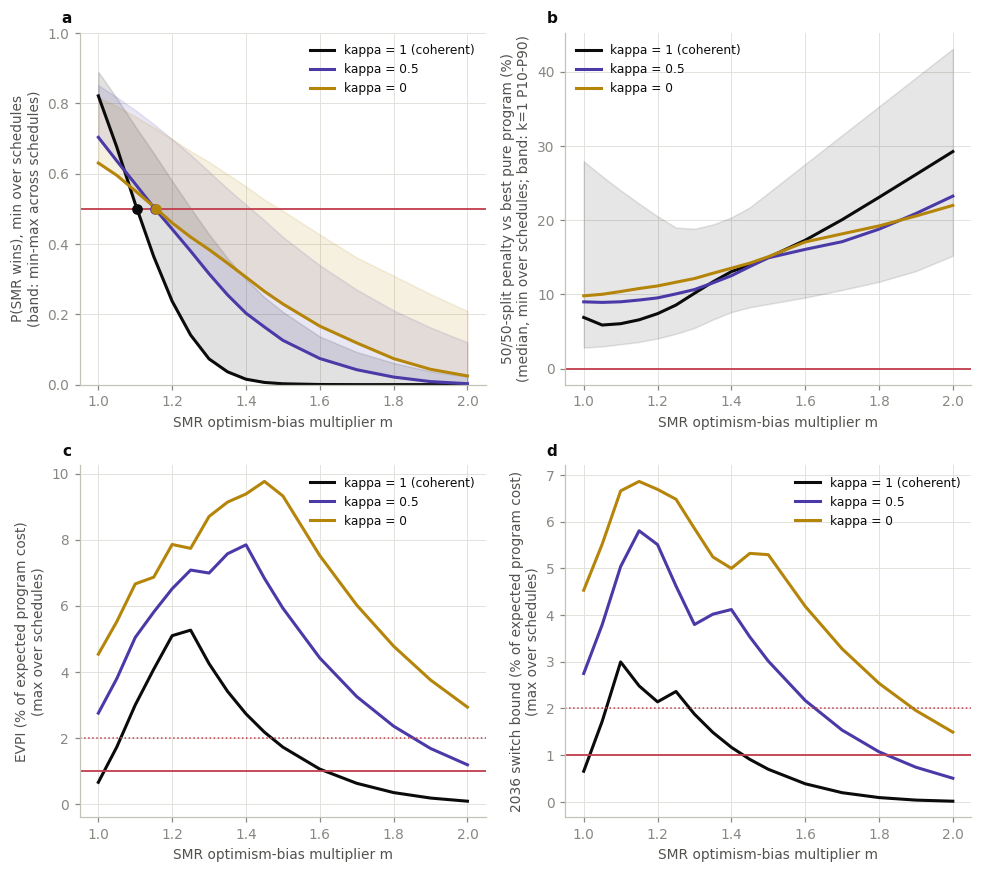

In [13]:
# S4 - the flip-curve figure.
KCOL = {"k100": INK, "k050": ps.ACCENT["violet"], "k000": ps.ACCENT["gold"]}
KLAB = {"k100": "κ = 1 (fully coupled)", "k050": "κ = 0.5", "k000": "κ = 0 (independent)"}

fig, axes = plt.subplots(2, 2, figsize=(ps.W2, 8.0))
ms_all = np.array(sorted(SWEEP["m"].unique()))

ax = axes[0, 0]
for aid in AIDS:
    g = SWEEP[SWEEP["cell"] == aid].groupby("m")
    ax.fill_between(ms_all, g["P_smr"].min().loc[ms_all], g["P_smr"].max().loc[ms_all],
                    color=KCOL[aid], alpha=0.12)
    ax.plot(ms_all, g["P_smr"].min().loc[ms_all], color=KCOL[aid], lw=2, label=KLAB[aid])
    r = BOUNDS[(BOUNDS["cell"] == aid) & (BOUNDS["claim"] == "S2-d majority")
               & (BOUNDS["schedule"] == "min over schedules")].iloc[0]
    if np.isfinite(r["m_star"]) and not r["note"]:
        ax.plot([r["m_star"]], [0.5], "o", color=KCOL[aid], ms=6, zorder=5)
ax.axhline(0.5, color=ps.ACCENT["red"], lw=1.2)
ax.set_ylabel("probability the all-SMR program is cheaper\n(line: lowest schedule; band: range across schedules)")
ax.set_ylim(0, 1)
ax.legend(fontsize=8, loc="upper right")

ax = axes[0, 1]
for aid in AIDS:
    g = SWEEP[(SWEEP["cell"] == aid)].groupby("m")
    if aid == "k100":
        ax.fill_between(ms_all, g["frag_npv_P10"].min().loc[ms_all],
                        g["frag_npv_P90"].max().loc[ms_all], color=KCOL[aid], alpha=0.10)
    ax.plot(ms_all, g["frag_npv_P50"].min().loc[ms_all], color=KCOL[aid], lw=2,
            label=KLAB[aid])
ax.axhline(0.0, color=ps.ACCENT["red"], lw=1.2)
ax.set_ylabel("50/50-split penalty vs best pure program (%)\n"
              "(median, min over schedules; band: k=1 P10-P90)")
ax.legend(fontsize=8, loc="upper left")

for ax, col, lab in [(axes[1, 0], "EVPI_pct", "EVPI (% of expected program cost)"),
                     (axes[1, 1], "bound_pct",
                      "2036 switch bound (% of expected program cost)")]:
    for aid in AIDS:
        g = SWEEP[SWEEP["cell"] == aid].groupby("m")
        ax.plot(ms_all, g[col].max().loc[ms_all], color=KCOL[aid], lw=2, label=KLAB[aid])
    ax.axhline(C5_THRESH_PCT, color=ps.ACCENT["red"], lw=1.2)
    ax.axhline(2.0, color=ps.ACCENT["red"], lw=1.0, ls=":")
    ax.set_ylabel(lab + "\n(max over schedules)")
    ax.legend(fontsize=8, loc="upper right")

for ax in axes.ravel():
    ax.set_xlabel("SMR optimism-bias multiplier m\n(true SMR cost = m × sampled cost)")
ps.letter_panels(list(axes.ravel()))
plt.tight_layout()
ps.savefig(fig, FIGURES / "obs_flip_curves.png")
plt.show()


## S4b — Paper Fig 3 panels c and d

The 2026-08-26 sweep replaced the main paper's Fig 3c (EVPI vs κ) and Fig 3d (2036
switch bound vs κ) with optimism-bias sweep curves. The 2026-08-31 third recomposition
(Ethan, S2 drafting) re-paired the 2×2 as winner/value-of-waiting × baseline/optimism:
panel c is now the **majority flip curve** (S4's panel a at paper size) and panel d the
**EVPI sweep**. The standalone bound sweep `obs_bound_vs_m.png` is retired from the
paper (the file on disk is a record artifact with its historical baked "d"): the
bound-vs-m curve stays in `obs_flip_curves.png` (SI, the flip-curve page), and the
baseline bound κ-profile moved into main Fig 3b (`tech_comparison.ipynb`, cell t8c).
House rule: the internally lettered source carries the FINAL panel letters ("c", "d");
the paper compose runs with `letters=""`.

*Figure note (saved: `obs_majority_vs_m.png`, `obs_evpi_vs_m.png`): min-over-schedules
P(SMR wins) with the min–max band, the 0.5 majority line, and the interpolated flip
points (c); max-over-schedules EVPI with the pre-registered 1% C5 threshold and its
interpolated crossings (d) — both against the optimism multiplier m per dependence
anchor.*


saved -> figures\obs_majority_vs_m.png


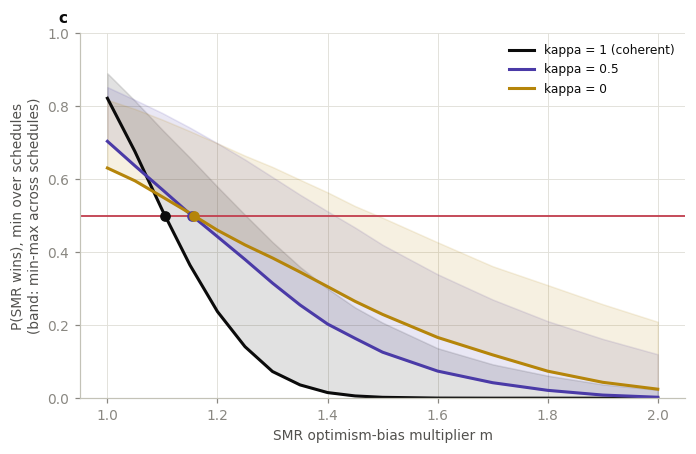

saved -> figures\obs_evpi_vs_m.png


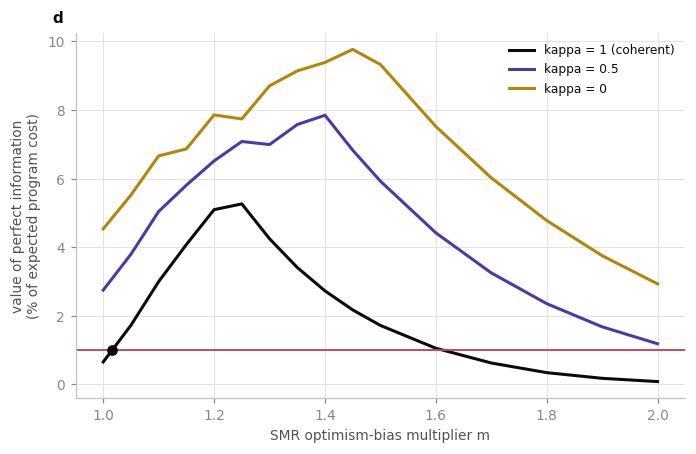

In [14]:
# S4b - paper Fig 3 panels c and d (baked final letters; composed with letters="").
# Recomposed 2026-08-31: c = the majority flip curve, d = the EVPI sweep. The
# standalone bound sweep (obs_bound_vs_m.png) is retired from the paper -- its
# curve stays in obs_flip_curves.png (SI flip-curve page), and the baseline bound
# kappa-profile is main Fig 3b (tech_comparison t8c).

# panel c - the majority claim vs m (S4's panel a at paper-panel size)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
for aid in AIDS:
    g = SWEEP[SWEEP["cell"] == aid].groupby("m")
    ax.fill_between(ms_all, g["P_smr"].min().loc[ms_all], g["P_smr"].max().loc[ms_all],
                    color=KCOL[aid], alpha=0.12)
    ax.plot(ms_all, g["P_smr"].min().loc[ms_all], color=KCOL[aid], lw=2, label=KLAB[aid])
    r = BOUNDS[(BOUNDS["cell"] == aid) & (BOUNDS["claim"] == "S2-d majority")
               & (BOUNDS["schedule"] == "min over schedules")].iloc[0]
    if np.isfinite(r["m_star"]) and not r["note"]:
        ax.plot([r["m_star"]], [0.5], "o", color=KCOL[aid], ms=6, zorder=5)
ax.axhline(0.5, color=ps.ACCENT["red"], lw=1.2)
ax.set_xlabel("SMR optimism-bias multiplier m\n(true SMR cost = m × sampled cost)")
ax.set_ylabel("probability the all-SMR program is cheaper\n(line: lowest schedule; band: range across schedules)")
ax.set_ylim(0, 1)
ax.legend(fontsize=8, loc="upper right")
ps.panel_letter(ax, "c")
fig.tight_layout()
ps.savefig(fig, FIGURES / "obs_majority_vs_m.png")
plt.show()

# panel d - the EVPI sweep (baked letter c until 2026-08-31)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
for aid in AIDS:
    g = SWEEP[SWEEP["cell"] == aid].groupby("m")
    ax.plot(ms_all, g["EVPI_pct"].max().loc[ms_all], color=KCOL[aid], lw=2,
            label=KLAB[aid])
ax.axhline(C5_THRESH_PCT, color=ps.ACCENT["red"], lw=1.2)
for aid in AIDS:
    r = BOUNDS[(BOUNDS["cell"] == aid) & (BOUNDS["claim"] == "S2-c1 EVPI")
               & (BOUNDS["criterion"] == f"EVPI crosses {C5_THRESH_PCT}%")].iloc[0]
    if np.isfinite(r["m_star"]) and not r["note"]:
        ax.plot([r["m_star"]], [C5_THRESH_PCT], "o", color=KCOL[aid], ms=6, zorder=5)
ax.set_xlabel("SMR optimism-bias multiplier m\n(true SMR cost = m × sampled cost)")
ax.set_ylabel("value of perfect information\n(% of expected program cost)")
ax.legend(fontsize=8, loc="upper right")
ps.panel_letter(ax, "d")
fig.tight_layout()
ps.savefig(fig, FIGURES / "obs_evpi_vs_m.png")
plt.show()


In [15]:
# S5 - exports + metadata (tc_metadata pattern: seed, grid, streams, file hashes).
SWEEP.to_csv(EXPORTS / "sweep_metrics.csv", index=False)
BOUNDS.to_csv(EXPORTS / "flip_boundaries.csv", index=False)

def _sha(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

meta = {
    "master_seed": MASTER_SEED,
    "n_draws": N_DRAWS_TC,
    "m_grid": [float(m) for m in M_GRID],
    "anchors": AIDS,
    "thresholds": {"majority": 0.5, "evpi_pct": EVPI_THRESHOLDS,
                   "bound_pct": C5_THRESH_PCT, "frag_median_pct": 0.0},
    "stream_note": ("kappa<1 draws reuse tech_comparison's ob-cell streams "
                    "(tccomp/world/ob@{aid}/{tok}), held fixed across all m: "
                    "common random numbers + bit-exact m=1.5 pins. kappa=1 uses the "
                    "frozen mc_perdraw.npz uniforms (deterministic)."),
    "streams_used": sorted(set(STREAMS_USED)),
    "files": {f: _sha(EXPORTS / f) for f in ["sweep_metrics.csv", "flip_boundaries.csv"]},
}
(EXPORTS / "ob_sweep_metadata.json").write_text(json.dumps(meta, indent=1) + "\n",
                                                encoding="utf-8")
print(f"exports written -> {EXPORTS}")
for f, h in meta["files"].items():
    print(f"  {f}  sha256 {h[:16]}...")


exports written -> C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc\exports\ob_sweep
  sweep_metrics.csv  sha256 526158cd5d5d9fde...
  flip_boundaries.csv  sha256 96a91faefda0bf20...


## S6 — QA: pins to the published exports

The sweep must land exactly on the published tech_comparison numbers at both ends:

- **QA-1 (exact, m = 1.5):** min/max P(SMR) over schedules reproduces the
  `stress_survival.csv` `ob@k100/k050/k000` rows — same streams, same engine, so the
  match is bit-for-bit (compared at the CSV's 4-decimal precision).
- **QA-2 (exact to float noise, m = 1.0 at κ = 1):** per-schedule P(SMR), EVPI, and the
  switch bound reproduce the published `robustness_map.csv` / `evpi_total.csv` /
  `adaptive_value.csv` k100 rows. The sweep re-derives the marginals from the recovered
  npz uniforms (the `variant="ob"` path), so agreement is to ~1e-9 float error, not
  bit-for-bit — tolerance 1e-3.
- **QA-3 (statistical, m = 1.0 at κ = 0.5/0):** the sweep's baseline estimate uses the
  ob-cell streams, not the baseline streams, so it must match the published baseline
  within Monte Carlo error (tolerance 0.03 on P, 0.5 pp on EVPI/bound).
- **QA-4 (S13 cross-check):** at m = 1.0, κ = 1, the capex-object 50/50 penalty median
  for McKinsey reproduces the S13 fragmentation headline (16.7%, tolerance 0.6 pp) —
  same frozen worlds, same arithmetic, independent implementation.
- **QA-5 (monotonicity):** P(SMR) is non-increasing in m — exactly at κ = 1 (shared
  draws; the SMR program cost is strictly increasing in m per draw), and up to a 0.02
  rejection-resampling tolerance at κ < 1.

All pins are skipped (with a notice) on smoke runs below 10k draws.


In [16]:
# S6 - QA pins.
TC_EXP = MC_EXPORTS / "tech_comparison"
qa_fail = []

def qa(name, ok, detail):
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}: {detail}")
    if not ok:
        qa_fail.append(name)

if N_DRAWS_TC < 10000:
    print(f"SMOKE RUN ({N_DRAWS_TC} draws): published-export pins skipped.")
else:
    # QA-1: m=1.5 reproduces the stress rows bit-for-bit (CSV 4-decimal precision).
    stress = pd.read_csv(TC_EXP / "stress_survival.csv")
    for aid in AIDS:
        pub = stress[(stress["stress"] == "OB x1.5")
                     & (stress["cell"] == f"ob@{aid}")].iloc[0]
        sub = SWEEP[(SWEEP["cell"] == aid) & (SWEEP["m"] == 1.5)]
        lo, hi = sub["P_smr"].min(), sub["P_smr"].max()
        ok = (abs(round(lo, 4) - pub["min_P_smr"]) <= 5e-5
              and abs(round(hi, 4) - pub["max_P_smr"]) <= 5e-5)
        qa(f"QA-1 ob@{aid}", ok, f"sweep {lo:.4f}/{hi:.4f} vs published "
                                 f"{pub['min_P_smr']}/{pub['max_P_smr']}")

    # QA-2: m=1.0 at kappa=1 reproduces the published baseline (float-noise tolerance).
    rob = pd.read_csv(TC_EXP / "robustness_map.csv")
    evp = pd.read_csv(TC_EXP / "evpi_total.csv")
    ada = pd.read_csv(TC_EXP / "adaptive_value.csv")
    sub = SWEEP[(SWEEP["cell"] == "k100") & (SWEEP["m"] == 1.0)].set_index("schedule")
    for name, pub_df, pub_col, swp_col, tol in [
            ("P(SMR)", rob, "P_smr", "P_smr", 1e-3),
            ("EVPI", evp, "EVPI_pct", "EVPI_pct", 1e-3),
            ("bound", ada, "bound_pct", "bound_pct", 1e-3)]:
        pub = pub_df[pub_df["cell"] == "k100"].set_index("schedule")[pub_col]
        diff = (sub[swp_col] - pub).abs().max()
        qa(f"QA-2 k100 {name}", diff <= tol, f"max |diff| = {diff:.2e} (tol {tol})")

    # QA-3: m=1.0 at kappa=0.5/0 matches the published baseline within MC error.
    for aid in ("k050", "k000"):
        sub = SWEEP[(SWEEP["cell"] == aid) & (SWEEP["m"] == 1.0)].set_index("schedule")
        pubP = rob[rob["cell"] == aid].set_index("schedule")["P_smr"]
        dP = (sub["P_smr"] - pubP).abs().max()
        pubE = evp[evp["cell"] == aid].set_index("schedule")["EVPI_pct"]
        dE = (sub["EVPI_pct"] - pubE).abs().max()
        pubB = ada[ada["cell"] == aid].set_index("schedule")["bound_pct"]
        dB = (sub["bound_pct"] - pubB).abs().max()
        qa(f"QA-3 {aid}", dP <= 0.03 and dE <= 0.5 and dB <= 0.5,
           f"max |dP| = {dP:.4f} (tol 0.03), |dEVPI| = {dE:.3f}, "
           f"|dbound| = {dB:.3f} (tol 0.5)")

    # QA-4: S13 fragmentation headline (16.7% median, capex object, McKinsey, kappa=1).
    v = SWEEP[(SWEEP["cell"] == "k100") & (SWEEP["m"] == 1.0)
              & (SWEEP["schedule"] == REP_SCHED)]["frag_cap_P50"].iloc[0]
    qa("QA-4 S13 fragmentation", abs(v - 16.7) <= 0.6,
       f"capex-object split penalty median {v:.2f}% vs S13 16.7% (tol 0.6)")

# QA-5: monotonicity (runs at any draw count).
worst = {}
for (aid, sched), grp in SWEEP.groupby(["cell", "schedule"]):
    d = np.diff(grp.sort_values("m")["P_smr"].to_numpy())
    worst[aid] = max(worst.get(aid, 0.0), float(d.max()) if len(d) else 0.0)
qa("QA-5 monotonicity k100", worst["k100"] <= 1e-12,
   f"max P(SMR) increase step = {worst['k100']:.2e} (exact expected)")
qa("QA-5 monotonicity k050/k000", max(worst["k050"], worst["k000"]) <= 0.02,
   f"max increase step = {max(worst['k050'], worst['k000']):.4f} (tol 0.02)")

assert not qa_fail, f"QA failures: {qa_fail}"
print("\nQA complete: all pins green.")


  [PASS] QA-1 ob@k100: sweep 0.0024/0.2066 vs published 0.0024/0.2066
  [PASS] QA-1 ob@k050: sweep 0.1259/0.4197 vs published 0.1259/0.4197
  [PASS] QA-1 ob@k000: sweep 0.2293/0.4939 vs published 0.2293/0.4939
  [PASS] QA-2 k100 P(SMR): max |diff| = 0.00e+00 (tol 0.001)
  [PASS] QA-2 k100 EVPI: max |diff| = 0.00e+00 (tol 0.001)
  [PASS] QA-2 k100 bound: max |diff| = 8.33e-17 (tol 0.001)
  [PASS] QA-3 k050: max |dP| = 0.0179 (tol 0.03), |dEVPI| = 0.270, |dbound| = 0.110 (tol 0.5)
  [PASS] QA-3 k000: max |dP| = 0.0071 (tol 0.03), |dEVPI| = 0.057, |dbound| = 0.036 (tol 0.5)
  [PASS] QA-4 S13 fragmentation: capex-object split penalty median 16.68% vs S13 16.7% (tol 0.6)
  [PASS] QA-5 monotonicity k100: max P(SMR) increase step = 0.00e+00 (exact expected)
  [PASS] QA-5 monotonicity k050/k000: max increase step = 0.0000 (tol 0.02)

QA complete: all pins green.
